<a href="https://colab.research.google.com/github/WVF-1/Computation-Budget/blob/main/GIN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive Computational Scheduler — GIN Backbone

**Model 3 of 5: Moderate.** Same scheduler (Cost, MED, BEU, Thompson
Sampling, Budget) as GraphSAGE/GAT, now wrapped around a Graph
Isomorphism Network (GIN) backbone -- sum-aggregation through an MLP,
chosen for maximal theoretical expressiveness under the
Weisfeiler-Lehman test, a meaningfully different inductive bias from
GCN/GAT's smoothing-style aggregation or GraphSAGE's sampled mean.

**Attention fallback (Option A)**: GIN has no native attention (sum
aggregation via `GINConv`), so this reverts to the `GATAttentionScorer`
side-channel used for GraphSAGE -- not GAT's native-attention pattern.

**Real data only** (Cora, Citeseer), 100 runs total -- same trimming
applied to GAT, per instruction.

**Everything else unchanged**: Cost/MED/BEU/Thompson Sampling copied
verbatim from the frozen scheduler file; symmetric regularization
(dropout, weight decay, early stopping via `val_mask` on both models) --
confirmed working cleanly on the GAT results you just uploaded (both
Cora and Citeseer showed clean wins with no reversal, unlike V2).

## Setup

In [1]:
!pip install -q torch_geometric networkx scikit-learn matplotlib numpy scipy pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.6 MB/s eta 0:00:00


In [2]:
import time
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import skew, ttest_rel, chi2

from torch_geometric.nn import GINConv
from torch_geometric.data import Data
from torch_geometric.utils import k_hop_subgraph
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


## `data.py` — real-data loading only (unchanged from GAT/GraphSAGE)

In [3]:
REAL_DATA_URLS = {
    "cora": "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz",
    "citeseer": "https://linqs-data.soe.ucsc.edu/public/lbc/citeseer.tgz",
}
REAL_DATA_ROOT = "real_data"


def ensure_real_dataset_downloaded(name):
    """Downloads + extracts cora.tgz/citeseer.tgz from the canonical LINQS
    source if not already present; falls back to a Colab upload prompt."""
    target_dir = os.path.join(REAL_DATA_ROOT, name)
    content_path = os.path.join(target_dir, f"{name}.content")

    if os.path.exists(content_path):
        return target_dir

    os.makedirs(REAL_DATA_ROOT, exist_ok=True)
    tgz_path = os.path.join(REAL_DATA_ROOT, f"{name}.tgz")

    url = REAL_DATA_URLS[name]
    print(f"Downloading {name} from {url} ...")
    result = os.system(f"wget -q -O {tgz_path} {url}")

    if result != 0 or not os.path.exists(tgz_path) or os.path.getsize(tgz_path) == 0:
        print(f"Download failed -- please upload {name}.tgz manually when prompted.")
        try:
            from google.colab import files
            uploaded = files.upload()
            for fname in uploaded:
                if fname.endswith(".tgz"):
                    os.rename(fname, tgz_path)
        except ImportError:
            raise RuntimeError(
                f"Could not download {name}.tgz and this isn't running in "
                f"Colab. Place {name}.tgz in '{REAL_DATA_ROOT}/' manually."
            )

    os.system(f"tar xzf {tgz_path} -C {REAL_DATA_ROOT}")
    return target_dir


def load_real_dataset(name, train_frac=0.6, val_frac=0.2, seed=None):
    """Load Cora/Citeseer (LINQS .content/.cites format) into a Data
    object with a fresh random 60/20/20 split -- unchanged from V2."""
    root_dir = ensure_real_dataset_downloaded(name)
    rng = np.random.default_rng(seed)

    content_path = os.path.join(root_dir, f"{name}.content")
    cites_path = os.path.join(root_dir, f"{name}.cites")

    paper_ids, features, labels_str = [], [], []
    with open(content_path) as f:
        for line in f:
            parts = line.split()
            paper_ids.append(parts[0])
            features.append([int(v) for v in parts[1:-1]])
            labels_str.append(parts[-1])

    id_to_idx = {pid: i for i, pid in enumerate(paper_ids)}
    num_nodes = len(paper_ids)

    x = torch.tensor(features, dtype=torch.float)

    unique_labels = sorted(set(labels_str))
    label_to_int = {lbl: i for i, lbl in enumerate(unique_labels)}
    y = torch.tensor([label_to_int[l] for l in labels_str], dtype=torch.long)

    edges = []
    with open(cites_path) as f:
        for line in f:
            parts = line.split()
            if len(parts) != 2:
                continue
            cited, citing = parts
            if cited in id_to_idx and citing in id_to_idx:
                u, v = id_to_idx[citing], id_to_idx[cited]
                edges.append((u, v))
                edges.append((v, u))

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_index = torch.unique(edge_index, dim=1)

    data = Data(x=x, edge_index=edge_index, y=y)

    perm = rng.permutation(num_nodes)
    n_train = int(train_frac * num_nodes)
    n_val = int(val_frac * num_nodes)

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[torch.as_tensor(perm[:n_train])] = True
    val_mask[torch.as_tensor(perm[n_train:n_train + n_val])] = True
    test_mask[torch.as_tensor(perm[n_train + n_val:])] = True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    return data


## `model.py` — GIN backbone + reused attention fallback scorer

`GIN`/`DeepGIN`/`ScheduledGIN` mirror the GraphSAGE structure exactly,
with `GINConv` (sum aggregation through a 2-layer MLP, `train_eps=False`)
in place of `SAGEConv`. `GATAttentionScorer` is copied verbatim -- same
Option-A fallback role as it played for GraphSAGE.

In [4]:
def make_gin_mlp(in_dim, hidden_dim, out_dim):
    """Standard GIN MLP: Linear -> ReLU -> Linear, wrapped by GINConv's
    sum-aggregation + (1+eps)*self update rule."""
    return nn.Sequential(
        nn.Linear(in_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, out_dim),
    )


class GIN(nn.Module):
    """Shallow 2-layer GIN (sum aggregation via MLP). Default path for
    ScheduledGIN -- same role as GCN/GraphSAGE in prior notebooks."""

    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GINConv(make_gin_mlp(in_dim, hidden_dim, hidden_dim))
        self.conv2 = GINConv(make_gin_mlp(hidden_dim, hidden_dim, out_dim))

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        out = self.conv2(h, edge_index)
        return out, h


class DeepGIN(nn.Module):
    """Uniform, always-deep 3-layer GIN. The experimental control --
    paying full depth for every node, every epoch, with no scheduling."""

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.7):
        super().__init__()
        self.conv1 = GINConv(make_gin_mlp(in_dim, hidden_dim, hidden_dim))
        self.conv_deep = GINConv(make_gin_mlp(hidden_dim, hidden_dim, hidden_dim))
        self.conv2 = GINConv(make_gin_mlp(hidden_dim, hidden_dim, out_dim))
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv_deep(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.conv2(h, edge_index)
        return out, h


class ScheduledGIN(GIN):
    """
    Shallow 2-layer GIN by default, plus one extra hidden-to-hidden
    GINConv layer applied ONLY to scheduler-selected nodes, computed over
    the induced local subgraph. Same mechanism as ScheduledGraphSAGE.
    """

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.7):
        super().__init__(in_dim, hidden_dim, out_dim)
        self.extra_conv = GINConv(make_gin_mlp(hidden_dim, hidden_dim, hidden_dim))
        self.dropout = dropout

    def forward(self, x, edge_index, extra_pass_info=None):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)

        if extra_pass_info is not None:
            idx, subset, sub_edge_index, mapping = extra_pass_info
            h_sub = h[subset]
            h_extra_sub = F.relu(self.extra_conv(h_sub, sub_edge_index))
            h = h.clone()
            h[idx] = h_extra_sub[mapping]

        out = self.conv2(h, edge_index)
        return out, h


def build_extra_pass_subgraph(edge_index, selected_nodes, num_nodes):
    """Precompute the induced 1-hop subgraph around selected_nodes ONCE
    per reconsideration. Architecture-agnostic -- unchanged."""
    if selected_nodes is None or len(selected_nodes) == 0:
        return None

    idx = torch.as_tensor(selected_nodes, dtype=torch.long)
    subset, sub_edge_index, mapping, _ = k_hop_subgraph(
        idx, num_hops=1, edge_index=edge_index,
        relabel_nodes=True, num_nodes=num_nodes,
    )
    return idx, subset, sub_edge_index, mapping


class GATAttentionScorer(nn.Module):
    """
    Single-layer GAT-style attention scorer (verbatim from V0-V2).
    Fallback A_i source for backbones with no native attention
    (GraphSAGE, GIN, GCNII). NOT part of the classification forward pass.
    """

    def __init__(self, in_dim, hidden_dim, negative_slope=0.2):
        super().__init__()
        self.W = nn.Linear(in_dim, hidden_dim, bias=False)
        self.a = nn.Parameter(torch.empty(2 * hidden_dim))
        nn.init.xavier_uniform_(self.a.unsqueeze(0))
        self.leaky_relu = nn.LeakyReLU(negative_slope)

    def forward(self, h, edge_index):
        Wh = self.W(h)
        src, dst = edge_index

        edge_feat = torch.cat([Wh[src], Wh[dst]], dim=-1)
        e = self.leaky_relu(edge_feat @ self.a)

        a_ij = self._softmax_per_node(e, src, num_nodes=h.size(0))
        node_attention = self._scatter_mean(a_ij, src, num_nodes=h.size(0))

        return node_attention

    @staticmethod
    def _softmax_per_node(e, index, num_nodes):
        e = e - e.max()
        exp_e = torch.exp(e)
        denom = torch.zeros(num_nodes, device=e.device).scatter_add_(0, index, exp_e)
        denom = denom[index].clamp_min(1e-12)
        return exp_e / denom

    @staticmethod
    def _scatter_mean(values, index, num_nodes):
        sums = torch.zeros(num_nodes, device=values.device).scatter_add_(0, index, values)
        counts = torch.zeros(num_nodes, device=values.device).scatter_add_(
            0, index, torch.ones_like(values)
        )
        counts = counts.clamp_min(1)
        return sums / counts


## `scheduler.py` — Cost, MED, BEU, Thompson Sampling, Budget (frozen, verbatim, architecture-agnostic)

In [5]:
# ============================================================
# Scheduler V0 (Frozen)
# ============================================================

LAMBDA = 0.10
ALPHA = 0.01
MED_WEIGHTS = dict(
    attention=0.35,
    uncertainty=0.35,
    beu=0.20,
    cost=0.10,
)


def compute_uncertainty(logits):
    """Predictive entropy. U_i = -sum p_i log(p_i)"""
    probs = F.softmax(logits, dim=-1)
    log_probs = torch.log(probs.clamp_min(1e-12))
    entropy = -(probs * log_probs).sum(dim=-1)
    return entropy


class CostTracker:
    """C_i = number of times this node has been SELECTED so far
    (1st selection -> C_i=1, 2nd -> C_i=2, ...)."""

    def __init__(self, num_nodes):
        self.cost = np.zeros(num_nodes, dtype=np.float32)

    def register_selection(self, node_indices):
        idx = np.asarray(node_indices, dtype=np.int64)
        if idx.size == 0:
            return
        self.cost[idx] += 1

    def get_cost(self):
        return torch.tensor(self.cost, dtype=torch.float32)

    def reset(self):
        self.cost[:] = 0


class BudgetTracker:
    """Pure bookkeeping. Never affects scheduling decisions."""

    def __init__(self, num_nodes):
        self.budget = np.zeros(num_nodes, dtype=np.float32)

    def spend(self, node_indices, amount=1.0):
        idx = np.asarray(node_indices, dtype=np.int64)
        if idx.size == 0:
            return
        self.budget[idx] += amount

    @property
    def total_budget(self):
        return float(self.budget.sum())

    @property
    def avg_budget_per_node(self):
        return float(self.budget.mean())


def compute_beu(uncertainty, cost, lam=LAMBDA):
    """BEU_i = U_i - lambda * C_i"""
    return uncertainty - lam * cost


def compute_med(attention, uncertainty, beu, cost, weights=MED_WEIGHTS):
    """MED_i = 0.35*Attention + 0.35*Uncertainty + 0.20*BEU - 0.10*Cost"""
    return (
        weights["attention"] * attention
        + weights["uncertainty"] * uncertainty
        + weights["beu"] * beu
        - weights["cost"] * cost
    )


def laplace_smooth(med, alpha=ALPHA):
    """MED' = (MED + alpha) / (1 + alpha)"""
    return (med + alpha) / (1.0 + alpha)


class ThompsonSampler:
    """Every node is a multi-armed bandit arm; Thompson Sampling provides
    exploration, MED provides exploitation."""

    def __init__(self, num_nodes, prior_alpha=1.0, prior_beta=1.0):
        self.alpha = np.full(num_nodes, prior_alpha, dtype=np.float32)
        self.beta = np.full(num_nodes, prior_beta, dtype=np.float32)

    def select_nodes(self, med_scores, budget_fraction=0.10, budget_count=None):
        med_scores = med_scores.detach().cpu().numpy()
        sampled = np.random.beta(self.alpha, self.beta)

        med_norm = (
            med_scores - med_scores.min()
        ) / (
            med_scores.max() - med_scores.min() + 1e-12
        )

        gamma = 0.50
        combined = (1.0 - gamma) * sampled + gamma * med_norm

        if budget_count is not None:
            k = max(1, int(budget_count))
        else:
            k = max(1, int(len(combined) * budget_fraction))

        selected = np.argsort(combined)[-k:]
        return selected, combined, med_norm

    def update_from_outcome(self, node_indices, reward, threshold=0.0):
        """Reward = measured outcome (ambient-adjusted uncertainty
        reduction), NOT agreement with MED."""
        idx = np.asarray(node_indices, dtype=np.int64)
        if idx.size == 0:
            return

        reward = np.asarray(reward, dtype=np.float32)
        success_mask = reward > threshold

        self.alpha[idx[success_mask]] += 1
        self.beta[idx[~success_mask]] += 1


## `experiment.py` — training loops (attention-fallback pattern, same as GraphSAGE)

Unlike GAT, this uses a separate `attention_model` (GATAttentionScorer)
since GIN has no native attention -- structurally identical to
GraphSAGE's `train_scheduled`, just with GIN classes swapped in.
Symmetric regularization and the ambient-adjusted reward carried forward
unchanged.

In [6]:
BASELINE_LAYERS_PER_NODE = 3   # DeepGIN: conv1 + conv_deep + conv2
SHALLOW_LAYERS_PER_NODE = 2    # ScheduledGIN default path: conv1 + conv2
EXTRA_LAYER_COST = 1           # ScheduledGIN's extra_conv, selected nodes only


def train_baseline(data, hidden_dim=32, epochs=100, lr=0.01, seed=0,
                   weight_decay=1e-3, dropout=0.7, patience=20):
    """Baseline: DeepGIN, uniform 3-layer depth for every node, every epoch."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    num_nodes = data.x.size(0)
    num_classes = int(data.y.max().item() + 1)

    model = DeepGIN(data.x.size(1), hidden_dim, num_classes, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    budget_tracker = BudgetTracker(num_nodes)

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    start = time.time()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits, _ = model(data.x, data.edge_index)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        budget_tracker.spend(range(num_nodes), amount=BASELINE_LAYERS_PER_NODE)

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(data.x, data.edge_index)
            val_loss = F.cross_entropy(val_logits[data.val_mask], data.y[data.val_mask]).item()

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    runtime = time.time() - start

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        logits, _ = model(data.x, data.edge_index)
        preds = logits.argmax(dim=-1)

    return dict(
        preds=preds[data.test_mask],
        y=data.y[data.test_mask],
        runtime=runtime,
        total_budget=budget_tracker.total_budget,
        avg_budget_per_node=budget_tracker.avg_budget_per_node,
    )


def train_scheduled(data, hidden_dim=32, epochs=100, lr=0.01, seed=0,
                    budget_fraction=0.10, budget_count=None, reconsider_every=5,
                    weight_decay=1e-3, dropout=0.7, patience=20):
    """Scheduled GIN. Attention for MED's A_i comes from the separate
    GATAttentionScorer fallback (GIN has no native attention)."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    num_nodes = data.x.size(0)
    num_classes = int(data.y.max().item() + 1)

    model = ScheduledGIN(data.x.size(1), hidden_dim, num_classes, dropout=dropout)
    attention_model = GATAttentionScorer(hidden_dim, hidden_dim)

    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(attention_model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )

    cost_tracker = CostTracker(num_nodes)
    budget_tracker = BudgetTracker(num_nodes)
    sampler = ThompsonSampler(num_nodes)

    selected_nodes = np.array([], dtype=np.int64)
    extra_pass_info = None
    pending_nodes = np.array([], dtype=np.int64)
    prev_uncertainty_all = None

    med_history, combined_history, selection_history, reward_history = [], [], [], []

    best_val_loss = float("inf")
    best_state = None
    best_extra_pass_info = None
    epochs_without_improvement = 0

    start = time.time()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits, h = model(data.x, data.edge_index, extra_pass_info=extra_pass_info)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])

        logits_for_scheduling = logits.detach()
        h_for_scheduling = h.detach()

        loss.backward()
        optimizer.step()

        all_nodes = np.arange(num_nodes)
        budget_tracker.spend(all_nodes, amount=SHALLOW_LAYERS_PER_NODE)
        if len(selected_nodes) > 0:
            budget_tracker.spend(selected_nodes, amount=EXTRA_LAYER_COST)

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(data.x, data.edge_index, extra_pass_info=extra_pass_info)
            val_loss = F.cross_entropy(val_logits[data.val_mask], data.y[data.val_mask]).item()

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_extra_pass_info = extra_pass_info
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % reconsider_every == 0:
            with torch.no_grad():
                attention = attention_model(h_for_scheduling, data.edge_index)
                uncertainty = compute_uncertainty(logits_for_scheduling)
                cost = cost_tracker.get_cost()
                beu = compute_beu(uncertainty, cost)
                med = compute_med(attention, uncertainty, beu, cost)
                med = laplace_smooth(med)

            uncertainty_np = uncertainty.detach().cpu().numpy()

            if prev_uncertainty_all is not None and len(pending_nodes) > 0:
                delta_all = prev_uncertainty_all - uncertainty_np
                unselected_mask = np.ones(num_nodes, dtype=bool)
                unselected_mask[pending_nodes] = False
                baseline_delta = delta_all[unselected_mask].mean()
                reward = delta_all[pending_nodes] - baseline_delta
                sampler.update_from_outcome(pending_nodes, reward)
                reward_history.append(reward.copy())

            selected_nodes, combined, med_norm = sampler.select_nodes(
                med, budget_fraction, budget_count=budget_count,
            )
            cost_tracker.register_selection(selected_nodes)

            extra_pass_info = build_extra_pass_subgraph(data.edge_index, selected_nodes, num_nodes)

            prev_uncertainty_all = uncertainty_np
            pending_nodes = selected_nodes

            med_history.append(med.detach().cpu().numpy())
            combined_history.append(combined.copy())
            selection_history.append(selected_nodes.copy())

        if epochs_without_improvement >= patience:
            break

    runtime = time.time() - start

    if best_state is not None:
        model.load_state_dict(best_state)
        extra_pass_info = best_extra_pass_info

    model.eval()
    with torch.no_grad():
        logits, _ = model(data.x, data.edge_index, extra_pass_info=extra_pass_info)
        preds = logits.argmax(dim=-1)

    return dict(
        preds=preds[data.test_mask],
        y=data.y[data.test_mask],
        runtime=runtime,
        total_budget=budget_tracker.total_budget,
        avg_budget_per_node=budget_tracker.avg_budget_per_node,
        node_selection_counts=sampler.alpha - 1,
        med_history=med_history,
        combined_history=combined_history,
        selection_history=selection_history,
        reward_history=reward_history,
    )


## `metrics.py` — unchanged

In [7]:
def compute_classification_metrics(preds, y):
    preds = preds.cpu().numpy()
    y = y.cpu().numpy()
    return dict(
        accuracy=accuracy_score(y, preds),
        precision=precision_score(y, preds, average="macro", zero_division=0),
        recall=recall_score(y, preds, average="macro", zero_division=0),
        f1=f1_score(y, preds, average="macro", zero_division=0),
    )


def scheduler_efficiency(accuracy, total_budget):
    """Scheduler Efficiency = Accuracy / Computational Budget"""
    if total_budget == 0:
        return 0.0
    return accuracy / total_budget


## `plots.py` — five summary figures (unchanged functions)

In [8]:
FIGURE_DIR = "results/figures"


def _plot_full_and_aggregate(df, metric_col, title, ylabel, filename, med_mode=False,
                             group_col="group", group_values=("cora", "citeseer"),
                             output_dir=None):
    if output_dir is None:
        output_dir = FIGURE_DIR
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    sub = df.dropna(subset=[metric_col])

    if med_mode:
        data_to_plot = [sub[sub["model"] == "scheduled"][metric_col].values]
        labels = ["Scheduled"]
        colors = ["#4C72B0"]
    else:
        data_to_plot = [
            sub[sub["model"] == "baseline"][metric_col].values,
            sub[sub["model"] == "scheduled"][metric_col].values,
        ]
        labels = ["Baseline", "Scheduled"]
        colors = ["#888888", "#4C72B0"]

    bp = ax.boxplot(data_to_plot, tick_labels=labels, showfliers=False, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    rng = np.random.default_rng(0)
    for i, vals in enumerate(data_to_plot):
        x_jitter = rng.normal(loc=i + 1, scale=0.05, size=len(vals))
        ax.scatter(x_jitter, vals, alpha=0.35, s=12, color=colors[i], edgecolor="none")

    ax.set_title("All Runs")
    ax.set_ylabel(ylabel)

    ax2 = axes[1]
    groups = list(group_values)
    x = np.arange(len(groups))
    width = 0.35

    if med_mode:
        sched_means = [sub[(sub[group_col] == g) & (sub["model"] == "scheduled")][metric_col].mean() for g in groups]
        sched_stds = [sub[(sub[group_col] == g) & (sub["model"] == "scheduled")][metric_col].std() for g in groups]
        ax2.bar(x, sched_means, width, yerr=sched_stds, label="Scheduled", color="#4C72B0", capsize=4)
    else:
        base_means = [sub[(sub[group_col] == g) & (sub["model"] == "baseline")][metric_col].mean() for g in groups]
        base_stds = [sub[(sub[group_col] == g) & (sub["model"] == "baseline")][metric_col].std() for g in groups]
        sched_means = [sub[(sub[group_col] == g) & (sub["model"] == "scheduled")][metric_col].mean() for g in groups]
        sched_stds = [sub[(sub[group_col] == g) & (sub["model"] == "scheduled")][metric_col].std() for g in groups]

        ax2.bar(x - width / 2, base_means, width, yerr=base_stds, label="Baseline", color="#888888", capsize=4)
        ax2.bar(x + width / 2, sched_means, width, yerr=sched_stds, label="Scheduled", color="#4C72B0", capsize=4)

    ax2.set_xticks(x)
    ax2.set_xticklabels([g.capitalize() for g in groups])
    ax2.set_title(f"Aggregates by {group_col.capitalize()}")
    ax2.legend()

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, filename)
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")


def _plot_interaction_figure(df, group_col="group", group_values=("cora", "citeseer"),
                             output_dir=None):
    if output_dir is None:
        output_dir = FIGURE_DIR

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    groups = list(group_values)
    marker_shapes = ["o", "s", "^", "D", "v"]
    group_markers = {g: marker_shapes[i % len(marker_shapes)] for i, g in enumerate(groups)}
    model_colors = {"baseline": "#888888", "scheduled": "#4C72B0"}

    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=model_colors["baseline"], markersize=8, label="Baseline"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=model_colors["scheduled"], markersize=8, label="Scheduled"),
    ]
    for g in groups:
        legend_elems.append(
            Line2D([0], [0], marker=group_markers[g], color="gray", linestyle="None",
                   markersize=6, label=g.capitalize())
        )

    ax = axes[0]
    for model in ["baseline", "scheduled"]:
        for g in groups:
            sub = df[(df["model"] == model) & (df[group_col] == g)]
            ax.scatter(
                sub["total_budget"], sub["accuracy"],
                s=sub["runtime"] * 15 + 10,
                marker=group_markers[g], color=model_colors[model],
                alpha=0.5, edgecolor="white", linewidth=0.3,
            )
    ax.legend(handles=legend_elems, fontsize=8, loc="best")
    ax.set_xlabel("Total Budget")
    ax.set_ylabel("Accuracy")
    ax.set_title("All Runs (marker size = runtime)")

    ax2 = axes[1]
    for model in ["baseline", "scheduled"]:
        for g in groups:
            sub = df[(df["model"] == model) & (df[group_col] == g)]
            bx, by = sub["total_budget"].mean(), sub["accuracy"].mean()
            bxerr, byerr = sub["total_budget"].std(), sub["accuracy"].std()
            brt = sub["runtime"].mean()
            ax2.errorbar(
                bx, by, xerr=bxerr, yerr=byerr,
                marker=group_markers[g], color=model_colors[model],
                markersize=brt * 3 + 6, alpha=0.8, capsize=3, linestyle="None",
            )
    ax2.legend(handles=legend_elems, fontsize=8, loc="best")
    ax2.set_xlabel("Mean Total Budget")
    ax2.set_ylabel("Mean Accuracy")
    ax2.set_title(f"Aggregates by {group_col.capitalize()} (marker size = mean runtime)")

    fig.suptitle("Budget vs Accuracy Tradeoff (Runtime as Marker Size)", fontsize=14)
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, "5_interaction.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")


def generate_figures(df):
    group_values = ("cora", "citeseer")
    _plot_full_and_aggregate(df, "accuracy", "Accuracy: Baseline vs Scheduled", "Accuracy",
                             "1_accuracy.png", group_values=group_values)
    _plot_full_and_aggregate(df, "total_budget", "Computational Budget: Baseline vs Scheduled", "Total Budget",
                             "2_budget.png", group_values=group_values)
    _plot_full_and_aggregate(df, "runtime", "Runtime: Baseline vs Scheduled", "Runtime (s)",
                             "3_runtime.png", group_values=group_values)
    _plot_full_and_aggregate(df, "med_mean", "Mean MED Score (Scheduled only)", "Mean MED",
                             "4_med.png", med_mode=True, group_values=group_values)
    _plot_interaction_figure(df, group_values=group_values)


## `stats.py` — summary statistics + three hypothesis tests (unchanged methodology)

In [9]:
RESULTS_DIR = "results"


def compute_statistics(df, mcnemar_counts, group_col="group", output_dir=None):
    if output_dir is None:
        output_dir = RESULTS_DIR

    print("=" * 70)
    print(f"SUMMARY STATISTICS (grouped by {group_col} x model)")
    print("=" * 70)

    summary = df.groupby([group_col, "model"])[
        ["accuracy", "precision", "recall", "f1", "runtime",
         "total_budget", "avg_budget_per_node", "scheduler_efficiency"]
    ].agg(["mean", "std", "min", "max", "median"])

    print(summary)

    summary_path = os.path.join(output_dir, "summary_statistics.csv")
    summary.to_csv(summary_path)
    print(f"\nSaved summary statistics to {summary_path}")

    print("\n" + "=" * 70)
    print("HYPOTHESIS TESTS")
    print("=" * 70)

    pivot = df.pivot_table(index=[group_col, "seed"], columns="model",
                           values=["runtime", "total_budget"])

    rt_base = pivot[("runtime", "baseline")].values
    rt_sched = pivot[("runtime", "scheduled")].values
    t_rt, p_two_rt = ttest_rel(rt_base, rt_sched)
    p_one_rt = p_two_rt / 2 if t_rt > 0 else 1 - p_two_rt / 2
    print(f"\n1) Runtime -- paired t-test, H1: scheduled < baseline")
    print(f"   mean baseline={rt_base.mean():.4f}s | mean scheduled={rt_sched.mean():.4f}s")
    print(f"   t={t_rt:.3f}, one-sided p={p_one_rt:.6g}")

    bg_base = pivot[("total_budget", "baseline")].values
    bg_sched = pivot[("total_budget", "scheduled")].values
    t_bg, p_two_bg = ttest_rel(bg_base, bg_sched)
    p_one_bg = p_two_bg / 2 if t_bg > 0 else 1 - p_two_bg / 2
    print(f"\n2) Budget -- paired t-test, H1: scheduled < baseline")
    print(f"   mean baseline={bg_base.mean():.1f} | mean scheduled={bg_sched.mean():.1f}")
    print(f"   t={t_bg:.3f}, one-sided p={p_one_bg:.6g}")

    b, c = mcnemar_counts["mcnemar_b"], mcnemar_counts["mcnemar_c"]
    if b + c == 0:
        stat_mc, p_mc = 0.0, 1.0
    else:
        stat_mc = (abs(b - c) - 1) ** 2 / (b + c)
        p_mc = chi2.sf(stat_mc, df=1)
    print(f"\n3) Accuracy -- McNemar's test (chi-squared, 1 df)")
    print(f"   baseline-correct/scheduled-wrong (b) = {b}")
    print(f"   baseline-wrong/scheduled-correct (c) = {c}")
    print(f"   chi2={stat_mc:.3f}, p={p_mc:.6g}")
    if b + c > 0:
        direction = "baseline outperforms more often" if b > c else "scheduled outperforms more often"
        print(f"   ({direction} on discordant node-level predictions)")

    return summary


## `batch_runner.py` — 100 total runs (50 per dataset x 2 datasets)

In [10]:
RESULTS_BATCH_DIR = os.path.join(RESULTS_DIR, "batches")

CATEGORY_CONFIGS = {
    "cora":     dict(epochs=60, budget_count=30),
    "citeseer": dict(epochs=60, budget_count=30),
}
RUNS_PER_CATEGORY = 50
BATCH_SIZE = 10


def _run_one(category, seed):
    cfg = CATEGORY_CONFIGS[category]
    data = load_real_dataset(category, seed=seed)

    base = train_baseline(data, hidden_dim=32, epochs=cfg["epochs"], lr=0.01, seed=seed)
    sched = train_scheduled(
        data, hidden_dim=32, epochs=cfg["epochs"], lr=0.01, seed=seed,
        budget_count=cfg["budget_count"], reconsider_every=5,
    )

    base_metrics = compute_classification_metrics(base["preds"], base["y"])
    sched_metrics = compute_classification_metrics(sched["preds"], sched["y"])

    base_correct = (base["preds"] == base["y"]).numpy()
    sched_correct = (sched["preds"] == sched["y"]).numpy()

    all_med = np.concatenate(sched["med_history"]) if sched["med_history"] else np.array([np.nan])
    med_mean = float(np.nanmean(all_med))
    med_skew = float(skew(all_med)) if len(all_med) > 1 else float("nan")

    base_row = dict(
        group=category, seed=seed, model="baseline",
        accuracy=base_metrics["accuracy"], precision=base_metrics["precision"],
        recall=base_metrics["recall"], f1=base_metrics["f1"],
        runtime=base["runtime"], total_budget=base["total_budget"],
        avg_budget_per_node=base["avg_budget_per_node"],
        scheduler_efficiency=scheduler_efficiency(base_metrics["accuracy"], base["total_budget"]),
        med_mean=float("nan"), med_skew=float("nan"),
    )
    sched_row = dict(
        group=category, seed=seed, model="scheduled",
        accuracy=sched_metrics["accuracy"], precision=sched_metrics["precision"],
        recall=sched_metrics["recall"], f1=sched_metrics["f1"],
        runtime=sched["runtime"], total_budget=sched["total_budget"],
        avg_budget_per_node=sched["avg_budget_per_node"],
        scheduler_efficiency=scheduler_efficiency(sched_metrics["accuracy"], sched["total_budget"]),
        med_mean=med_mean, med_skew=med_skew,
    )

    return base_row, sched_row, base_correct, sched_correct


def run_study(runs_per_category=RUNS_PER_CATEGORY, batch_size=BATCH_SIZE, verbose=True):
    os.makedirs(RESULTS_BATCH_DIR, exist_ok=True)

    all_rows = []
    mcnemar_b = 0
    mcnemar_c = 0

    for category in ["cora", "citeseer"]:
        batch_rows = []
        batch_num = 0

        for i in range(runs_per_category):
            seed = i
            base_row, sched_row, base_correct, sched_correct = _run_one(category, seed)

            mcnemar_b += int((base_correct & ~sched_correct).sum())
            mcnemar_c += int((~base_correct & sched_correct).sum())

            batch_rows.append(base_row)
            batch_rows.append(sched_row)
            all_rows.append(base_row)
            all_rows.append(sched_row)

            if (i + 1) % batch_size == 0 or (i + 1) == runs_per_category:
                batch_num += 1
                batch_df = pd.DataFrame(batch_rows)
                batch_path = os.path.join(RESULTS_BATCH_DIR, f"batch_{category}_{batch_num:02d}.csv")
                batch_df.to_csv(batch_path, index=False)
                batch_rows = []

                if verbose:
                    print(f"[{category}] {i+1}/{runs_per_category} runs done -- saved {batch_path}")

    full_df = pd.DataFrame(all_rows)
    full_path = os.path.join(RESULTS_DIR, "all_results.csv")
    full_df.to_csv(full_path, index=False)

    print(f"\nSaved {len(full_df)} rows ({len(full_df)//2} runs) to {full_path}")

    return full_df, dict(mcnemar_b=mcnemar_b, mcnemar_c=mcnemar_c)


## Run the study

In [11]:
df, mcnemar_counts = run_study()


[cora] 10/50 runs done -- saved results/batches/batch_cora_01.csv
[cora] 20/50 runs done -- saved results/batches/batch_cora_02.csv
[cora] 30/50 runs done -- saved results/batches/batch_cora_03.csv
[cora] 40/50 runs done -- saved results/batches/batch_cora_04.csv
[cora] 50/50 runs done -- saved results/batches/batch_cora_05.csv
[citeseer] 10/50 runs done -- saved results/batches/batch_citeseer_01.csv
[citeseer] 20/50 runs done -- saved results/batches/batch_citeseer_02.csv
[citeseer] 30/50 runs done -- saved results/batches/batch_citeseer_03.csv
[citeseer] 40/50 runs done -- saved results/batches/batch_citeseer_04.csv
[citeseer] 50/50 runs done -- saved results/batches/batch_citeseer_05.csv

Saved 200 rows (100 runs) to results/all_results.csv


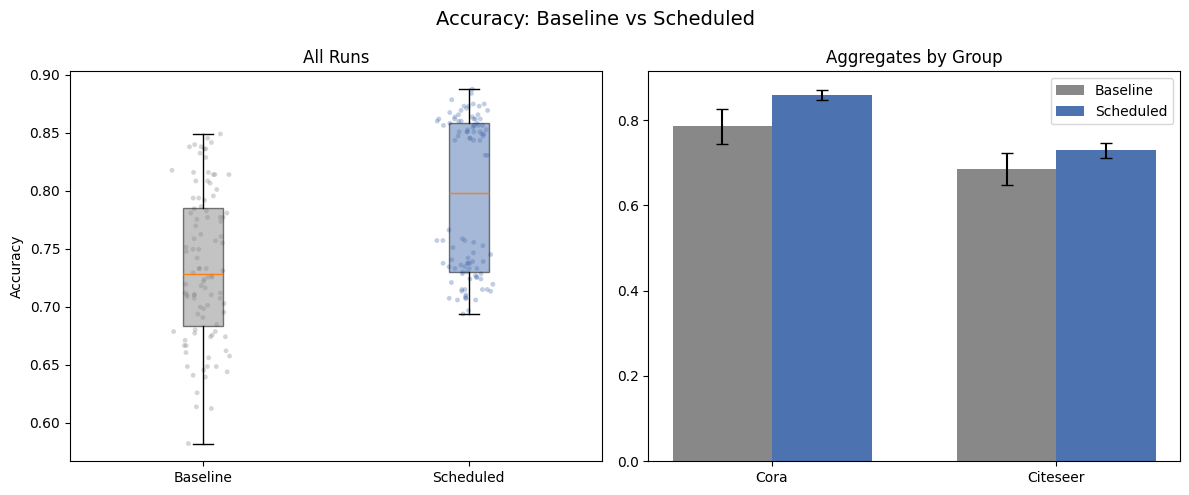

Saved: results/figures/1_accuracy.png


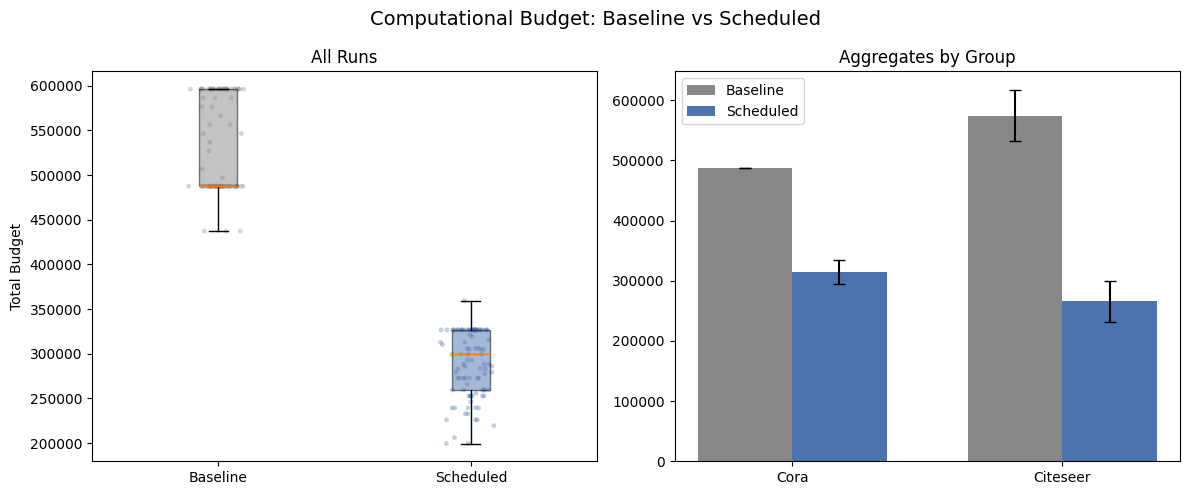

Saved: results/figures/2_budget.png


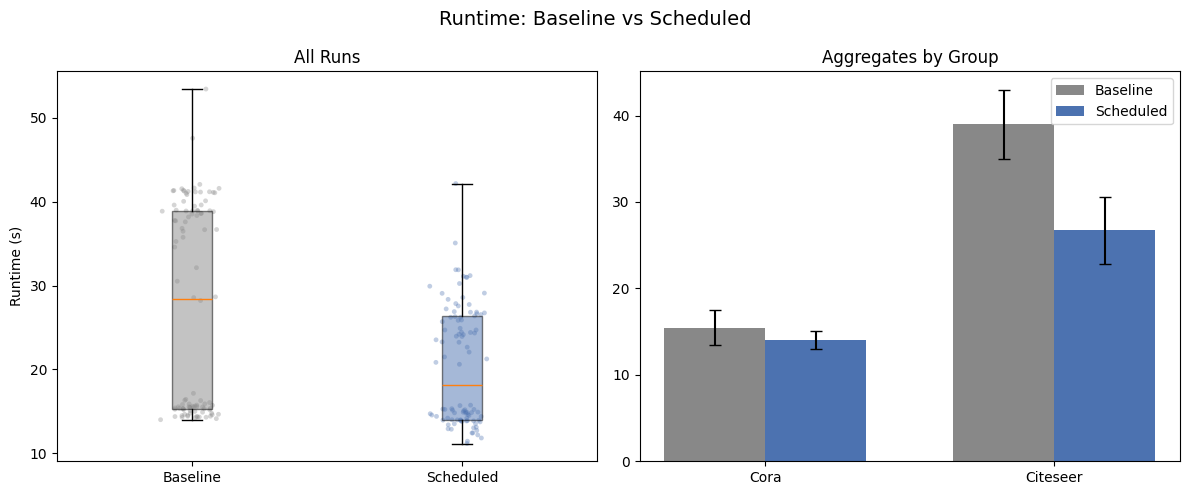

Saved: results/figures/3_runtime.png


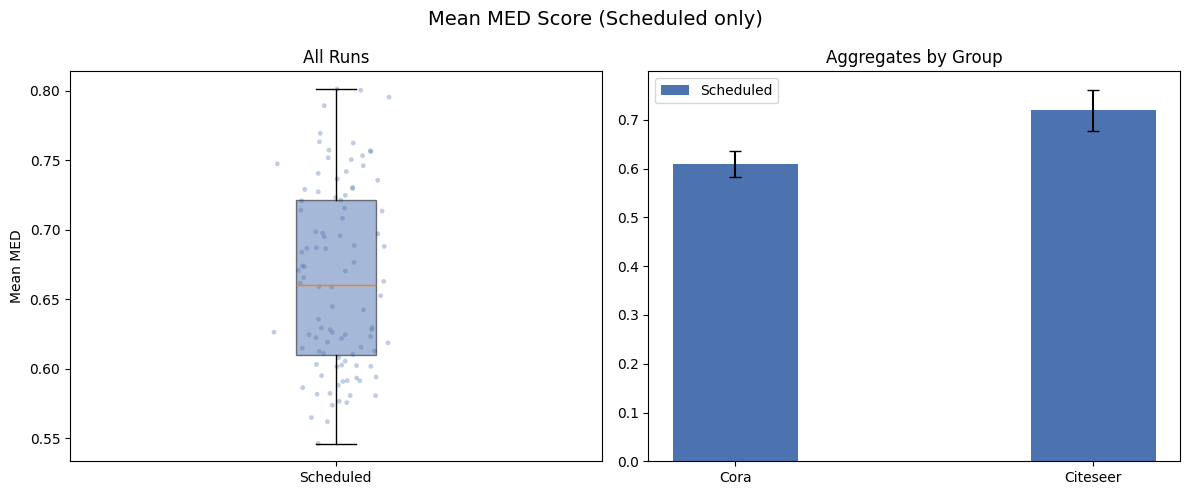

Saved: results/figures/4_med.png


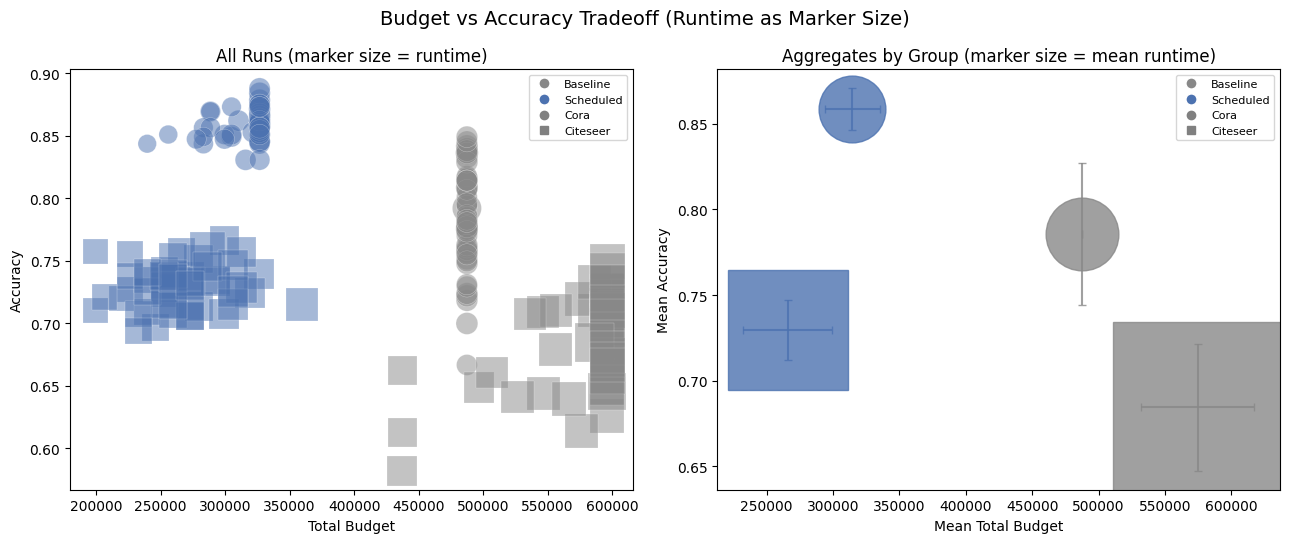

Saved: results/figures/5_interaction.png


In [12]:
generate_figures(df)


In [13]:
summary = compute_statistics(df, mcnemar_counts)


SUMMARY STATISTICS (grouped by group x model)
                    accuracy                                          \
                        mean       std       min       max    median   
group    model                                                         
citeseer baseline   0.684495  0.037106  0.582202  0.749623  0.687783   
         scheduled  0.729532  0.017453  0.693816  0.766214  0.730015   
cora     baseline   0.785488  0.041390  0.666667  0.848987  0.785451   
         scheduled  0.858600  0.012092  0.830571  0.887661  0.858195   

                   precision                                          ...  \
                        mean       std       min       max    median  ...   
group    model                                                        ...   
citeseer baseline   0.618816  0.054475  0.529712  0.748148  0.605786  ...   
         scheduled  0.695376  0.048276  0.590964  0.782445  0.701038  ...   
cora     baseline   0.758218  0.068847  0.607336  0.857606  0.78

## Optional: zip and download all results (Colab only)

In [14]:
import shutil

zip_path = shutil.make_archive("gin_results", "zip", RESULTS_DIR)
print(f"Zipped results to {zip_path}")

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not running in Google Colab -- skip the download step, "
          "the zip file is already saved locally.")


Zipped results to /content/gin_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>